# Aflevering 1

In [1]:
#import af pakker og fkt.
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import quad
from scipy.optimize import fsolve
from scipy.optimize import fmin

## a)

In [2]:
u = 12 #x-koordinat for centrum
v = 4 #y-koordinat for centrum
a = 9 #storakse
b = 3.8473 #lilleakse

#vi specificerer vores x variabel
x = np.linspace(-9, 9, 1000)

#vi opstiller y som 2 lambda-fkt. y og y1 
y = lambda x: b/a*np.sqrt(a**2-x**2)
y1 = lambda x: -b/a*np.sqrt(a**2-x**2)

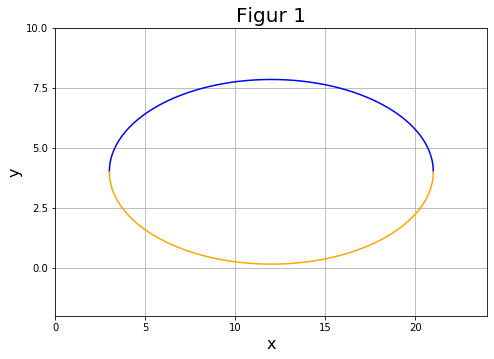

In [3]:
#definere plottet som en figur(kan anvendes til at indstille axerne)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])

ax.set_xticks(np.array([0, 5, 10, 15, 20]))
ax.set_yticks(np.array([0, 2.5, 5, 7.5, 10, 12.5]))
ax.set_xlim(0, 24)
ax.set_ylim(-2, 10)


#indsætter ellipsen
plt.plot(u+x, v+y(x), 'b')
plt.plot(u-x, v+y1(x), color='orange')

#tilpasser figuren
plt.title('Figur 1', fontsize=20)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.grid(linestyle='-')

## b)

In [4]:
#Vi importere sympy for at kunne differentiere y(x)
import sympy as sp
X = sp.symbols('X')
dydX = sp.diff(b/a*sp.sqrt(a**2-X**2))
print('dydX:', dydX)

#vi definerer dydX som en lambdafkt. dydX1
dydX1 = lambda X: -0.427477777777778*X/np.sqrt(81 - X**2)

#længden af et af linjestykkerne kan findes vha. quad fkt. fra scipy.integrate(python 2020, afsnit 7.5).
længde = quad(lambda X: np.sqrt(1+dydX1(X)**2 ), -9, 9)[0]

#omkredsen findes som 2*længden af linjestykkerne. 
omkreds = 2*længde
print('Omkreds:', omkreds)

dydX: -0.427477777777778*X/sqrt(81 - X**2)
Omkreds: 42.001111771263076


## c)

c-værdi: [8.136232709921712]
2a= 18
Sum: 18.0


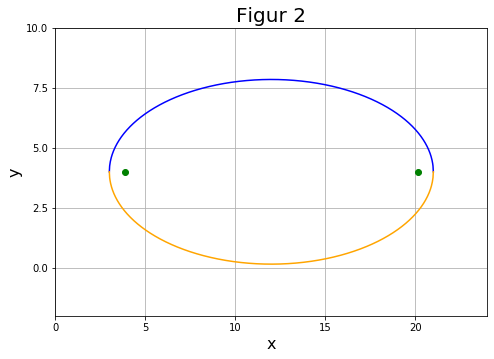

In [5]:
#Vi beregner c, der angiver afstanden fra centrum og
#ud til brændpunkter.
c = np.sqrt(a**2-b**2)

#definere plottet som en figur(kan anvendes til at indstille axerne)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_xticks(np.array([0, 5, 10, 15, 20]))
ax.set_yticks(np.array([0, 2.5, 5, 7.5, 10, 12.5]))
ax.set_xlim(0, 24)
ax.set_ylim(-2, 10)

#specifikationer for figur
plt.title('Figur 2', fontsize=20)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.grid(linestyle='-')

#vi plotter ellipsen 
plt.plot(u+x,v+y(x), 'b')
plt.plot(u-x,v+y1(x),color='orange')

#vi plotter brændpunkterne
plt.plot(-c+u, 0+v, 'go')
plt.plot(c+u, 0+v, 'go')

#numerisk beregning at summen af afstandene fra ellipsens toppunkt 
#for enden af storaksen til de to brændpunkter er 2a
print('c-værdi:',[c])
print('2a=', 2*a)
print('Sum:', u+a-(u-c)+u+a-(u+c))

plt.show()

## d)

2a= 18
Sum af linjestykker: 18.000000000000004


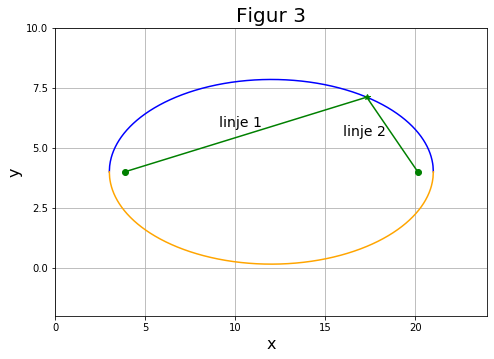

In [6]:
#Vi definerer plottet som en figur og indstiller akserne
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_xticks(np.array([0, 5, 10, 15, 20]))
ax.set_yticks(np.array([0, 2.5, 5, 7.5, 10, 12.5]))
ax.set_xlim(0, 24)
ax.set_ylim(-2, 10)


plt.plot(u+x,v+y(x), 'b')
plt.plot(u-x,v+y1(x),color='orange')

#Specifikationer for plottet
plt.title('Figur 3', fontsize=20)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.text(9.1, 5.9,'linje 1', fontsize=14)
plt.text(16, 5.5,'linje 2', fontsize=14)

plt.grid(linestyle='-')

#vi plotter vores brændpunkter
plt.plot(-c+u, 0+v, 'go')
plt.plot(c+u, 0+v, 'go')

#vi vælger et vilkårligt pkt. på ellipsen 
plt.plot(5.3+u, y(5.3)+v, 'g*')

#vi opstiller vores tre punkter som lister
pkt1 = [-c+u, 0+v]
pkt2 = [c+u, 0+v]
pkt3 = [5.3+u, y(5.3)+v]

x_linje1 = [pkt1[0], pkt3[0]]
y_linje1 = [pkt1[1], pkt3[1]]
x_linje2 = [pkt2[0], pkt3[0]]
y_linje2 = [pkt2[1], pkt3[1]]

#vi plotter de fundne linjer vha. plotfkt.
plt.plot(x_linje1, y_linje1, 'g')
plt.plot(x_linje2, y_linje2, 'g')

#vi beregner længden af linjestykkerne vha. pythagoras
kat1 = pkt3[0]-pkt1[0]
kat2 = pkt3[1]-pkt1[1]
hyp1 = np.sqrt(kat1**2+kat2**2)

kat3 = pkt2[0]-pkt3[0]
kat4 = pkt2[1]-pkt3[1]
hyp2 = np.sqrt(kat3**2+kat4**2)

#vi tjekker at summen af vores linjestykker svarer til 2*a
print('2a=', 2*a)
print('Sum af linjestykker:', hyp1+hyp2)

plt.show()

## e)

In [7]:
#vi opstiller en lambda for de to linjer under den betingelse, at den ene skal være lig 2 gange den anden.

f = lambda x: np.sqrt((-c-x)**2+y(x)**2)-2*np.sqrt((c-x)**2+(y(x))**2)

#vi bruger fsolve fkt. til at løse ligningen omkring x=3, idet vi tager højde for
#koordinaternes forskydning fra (0;0) senere.
x1 = fsolve(f,3)

print('x-værdi:',u-x1)

# vi tjekker at linje_1 = 2*linje_2, ved at anvende pythagoras
linje_1 = np.sqrt((c-x1)**2+y(x1)**2)
linje_2 = np.sqrt((c+x1)**2+y(x1)**2)

print('linje_1:', linje_1)
print('linje_2:', linje_2)
print('linje_2/linje_1:', linje_2/linje_1)

x-værdi: [8.68151085]
linje_1: [6.]
linje_2: [12.]
linje_2/linje_1: [2.]


## f)

Optimization terminated successfully.
         Current function value: -69.251400
         Iterations: 17
         Function evaluations: 34
Max vægt: [-42.0009741]


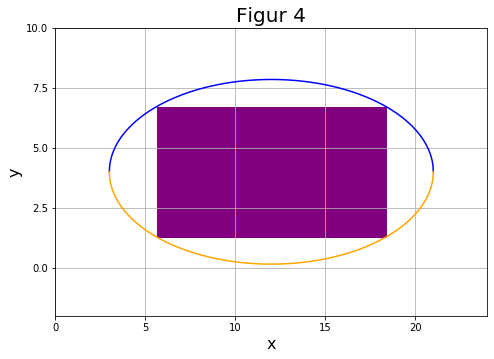

In [8]:
#Vores figur fra opgave 1
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_xticks(np.array([0, 5, 10, 15, 20]))
ax.set_yticks(np.array([0, 2.5, 5, 7.5, 10, 12.5]))
ax.set_xlim(0, 24)
ax.set_ylim(-2, 10)


#indsætter ellipsen
plt.plot(u+x, v+y(x), 'b')
plt.plot(u-x, v+y1(x), color='orange')

plt.title('Figur 4', fontsize=20)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.grid()

#vi definere en fkt. for vægten vores rektangel
f = lambda x:  -2*y(x)*2*abs(x)
xmin = fmin(f, -4)
xmax = abs(xmin)

#maximalvægt
print('Max vægt:', f(xmax)*0.6065)

#vi udfylder rektanglet vha. plt.fill
plt.fill([u-xmax, u-xmax, u+xmax, u+xmax],[-y(xmax)+v,y(xmax)+v,y(xmax)+v, -y(xmax)+v], color="purple")


In [9]:
f = lambda x:  -2*y(x)*2*abs(x)
xmin = fmin(f, -4)
abs(xmin)

Optimization terminated successfully.
         Current function value: -69.251400
         Iterations: 17
         Function evaluations: 34


array([6.36396484])